<a href="https://colab.research.google.com/github/dkumar-23/Masters_ML/blob/main/DRL_MAB_Clinical_Trials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi Armed Bandit Problem - Clinical Trials**

## Problem Statement

You are a data scientist working in cancer research in collaboration with a medical institution conducting clinical trials for different treatment protocols. A hospital is evaluating multiple medicines for treating a chronic disease, where patient responses vary due to hidden factors such as age, immunity level, genetic background, and disease severity.

Since the most effective treatment is not known at the beginning, the goal is to develop an **intelligent recommendation system** that learns from patient outcomes over time and progressively identifies the optimal medicine for future patients.

Each medicine is treated as an **arm** in a **Multi-Armed Bandit (MAB)** problem.

### Group Number: G = 170

### Dataset Parameters:
- **Number of Medicines (K):** (170 mod 3) + 5 = **7**
- **Hidden Success Probabilities:**
  - Medicine 0: P₀ = 0.4 + ((170+0) mod 6) × 0.07 = **0.54**
  - Medicine 1: P₁ = 0.4 + ((170+1) mod 6) × 0.07 = **0.61**
  - Medicine 2: P₂ = 0.4 + ((170+2) mod 6) × 0.07 = **0.68**
  - Medicine 3: P₃ = 0.4 + ((170+3) mod 6) × 0.07 = **0.75** ← Best medicine
  - Medicine 4: P₄ = 0.4 + ((170+4) mod 6) × 0.07 = **0.40**
  - Medicine 5: P₅ = 0.4 + ((170+5) mod 6) × 0.07 = **0.47**
  - Medicine 6: P₆ = 0.4 + ((170+6) mod 6) × 0.07 = **0.54**
- **Patients:** 1000 patients (patient_id 0 to 999)
- **Severity:** (patient_id mod 5) + 1 → values 1 (mild) to 5 (critical)
- **Utility Score:** clinical_outcome × (1 - Severity/10)


## Exploration vs. Exploitation

The central dilemma in the MAB problem is the trade-off between **exploration** (trying different medicines to gather information about their effectiveness) and **exploitation** (choosing the medicine that has provided the highest success rate based on current information). Balancing these two aspects is crucial for optimizing long-term patient outcomes.

---
## Environment Setup & Dataset Generation

We define a custom `ClinicalTrialMABEnv` class that simulates the clinical trial scenario.

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Group number
# ============================================================
G = 170

# Set seeds for reproducibility
random.seed(G)
np.random.seed(G)

# ============================================================
# Derived parameters
# ============================================================
K = (G % 3) + 5  # Number of medicines
print(f"Group Number (G): {G}")
print(f"Number of Medicines (K): {K}")

# Hidden success probabilities
hidden_probs = [0.4 + ((G + i) % 6) * 0.07 for i in range(K)]
print(f"\nHidden Success Probabilities (P_i):")
for i, p in enumerate(hidden_probs):
    best_marker = " ← Best" if p == max(hidden_probs) else ""
    print(f"  Medicine {i}: P_{i} = {p:.2f}{best_marker}")

NUM_PATIENTS = 1000
print(f"\nTotal Patients: {NUM_PATIENTS}")

patient_data = pd.DataFrame({
    "patient_id": range(NUM_PATIENTS),
    "severity_score": [(i % 5) + 1 for i in range(NUM_PATIENTS)]
})
# Print the first 10 rows
print(patient_data.head(10))

Group Number (G): 170
Number of Medicines (K): 7

Hidden Success Probabilities (P_i):
  Medicine 0: P_0 = 0.54
  Medicine 1: P_1 = 0.61
  Medicine 2: P_2 = 0.68
  Medicine 3: P_3 = 0.75 ← Best
  Medicine 4: P_4 = 0.40
  Medicine 5: P_5 = 0.47
  Medicine 6: P_6 = 0.54

Total Patients: 1000
   patient_id  severity_score
0           0               1
1           1               2
2           2               3
3           3               4
4           4               5
5           5               1
6           6               2
7           7               3
8           8               4
9           9               5


In [ ]:
class ClinicalTrialMABEnv:
    """
    Custom environment simulating a Multi-Armed Bandit clinical trial problem.

    Each medicine (arm) has a hidden probability of successful recovery.
    Patient severity affects the utility score of treatment.

    Utility Score = clinical_outcome × (1 - Severity/10)
    """

    def __init__(self, medicine_probs, num_patients=1000, group_number=170):
        self.medicine_probs = medicine_probs  # Hidden success probabilities for each medicine
        self.num_medicines = len(medicine_probs)
        self.num_patients = num_patients
        self.group_number = group_number
        self.state = {}
        self.current_patient = 0
        self.reset()

    def get_severity(self, patient_id):
        """Compute disease severity for a patient."""
        return (patient_id % 5) + 1

    def step(self, action):
        """
        Assign medicine 'action' to the current patient.

        Returns:
            state: dict of reward histories per medicine
            utility: the utility score (reward)
            done: whether all patients have been treated
            info: dict with clinical_outcome, severity, patient_id
        """
        patient_id = self.current_patient
        severity = self.get_severity(patient_id)

        # Hidden success probability of the chosen medicine
        p = self.medicine_probs[action]

        # Clinical outcome: 1 (recovered) with prob P_i, 0 (not recovered) with prob 1-P_i
        r = random.random()
        clinical_outcome = 1 if r <= p else 0

        # Utility score: treatment benefit decreases for highly severe patients
        utility = clinical_outcome * (1 - severity / 10)

        self.state[action].append(utility)
        self.current_patient += 1
        done = self.current_patient >= self.num_patients

        info = {
            'patient_id': patient_id,
            'severity': severity,
            'clinical_outcome': clinical_outcome,
            'medicine': action
        }

        return self.state, utility, done, info

    def reset(self):
        """Reset the environment for a new trial run."""
        # Re-seed for reproducibility on each reset
        random.seed(self.group_number)
        np.random.seed(self.group_number)
        self.state = {}
        for i in range(self.num_medicines):
            self.state[i] = []
        self.current_patient = 0
        return self.state

    def render(self):
        """Display overall statistics of the clinical trial."""
        print(f"{'='*60}")
        print(f"Clinical Trial Summary (Group {self.group_number}, K={self.num_medicines})")
        print(f"{'='*60}")
        total_patients = 0
        total_utility = 0.0
        for i in range(self.num_medicines):
            trials = len(self.state[i])
            total_reward = sum(self.state[i])
            avg_reward = total_reward / trials if trials > 0 else 0
            total_patients += trials
            total_utility += total_reward
            print(f"  Medicine {i} | Trials: {trials:4d}, "
                  f"Total Utility: {total_reward:8.2f}, "
                  f"Avg Utility: {avg_reward:.4f}, "
                  f"Hidden P: {self.medicine_probs[i]:.2f}")
        print(f"{'='*60}")
        print(f"  Total Patients Treated: {total_patients}")
        print(f"  Total Cumulative Utility: {total_utility:.2f}")
        print(f"{'='*60}")

    def close(self):
        pass


def get_clinical_trial_env():
    """Create the clinical trial environment with group-specific parameters."""
    G = 170
    K = (G % 3) + 5
    probs = [0.4 + ((G + i) % 6) * 0.07 for i in range(K)]
    return ClinicalTrialMABEnv(probs, num_patients=1000, group_number=G)

# Verify the environment
env = get_clinical_trial_env()
print(f"Environment created with {env.num_medicines} medicines for {env.num_patients} patients.")
print(f"Medicine probabilities: {env.medicine_probs}")

Environment created with 7 medicines for 1000 patients.
Medicine probabilities: [0.54, 0.6100000000000001, 0.68, 0.75, 0.4, 0.47000000000000003, 0.54]


---
## Approach 1: Greedy Policy

The **Greedy Policy** works in two stages:

1. **Exploration Stage:** At the start, it tests each medicine a set number of times (n trials per medicine) to gather initial information about effectiveness.
2. **Exploitation Stage:** After exploration, it switches to only using the medicine that had the best outcome (highest average utility), and does not explore further.

In [ ]:
def greedy_policy(state, explore=10):
    """Greedy policy: explore each medicine 'explore' times, then exploit the best."""
    bandits = len(state)
    trials = sum([len(state[b]) for b in range(bandits)])
    total_explore_trials = bandits * explore

    # Exploration phase
    if trials < total_explore_trials:
        return trials % bandits

    # Exploitation phase
    avg_rewards = [sum(state[b]) / len(state[b]) if len(state[b]) > 0 else 0
                   for b in range(bandits)]
    best_bandit = np.argmax(avg_rewards)
    return best_bandit


def run_greedy_policy(num_patients, env, exploration=10):
    """Run the greedy policy for all patients."""
    state = env.reset()
    rewards = []

    for i in range(num_patients):
        action = greedy_policy(state, exploration)
        state, reward, done, info = env.step(action)
        rewards.append(reward)

    env.close()
    return env, rewards

Clinical Trial Summary (Group 170, K=7)
  Medicine 0 | Trials:   10, Total Utility:     4.90, Avg Utility: 0.4900, Hidden P: 0.54
  Medicine 1 | Trials:   10, Total Utility:     3.80, Avg Utility: 0.3800, Hidden P: 0.61
  Medicine 2 | Trials:   10, Total Utility:     4.30, Avg Utility: 0.4300, Hidden P: 0.68
  Medicine 3 | Trials:  940, Total Utility:   476.70, Avg Utility: 0.5071, Hidden P: 0.75
  Medicine 4 | Trials:   10, Total Utility:     1.90, Avg Utility: 0.1900, Hidden P: 0.40
  Medicine 5 | Trials:   10, Total Utility:     4.20, Avg Utility: 0.4200, Hidden P: 0.47
  Medicine 6 | Trials:   10, Total Utility:     3.20, Avg Utility: 0.3200, Hidden P: 0.54
  Total Patients Treated: 1000
  Total Cumulative Utility: 499.00


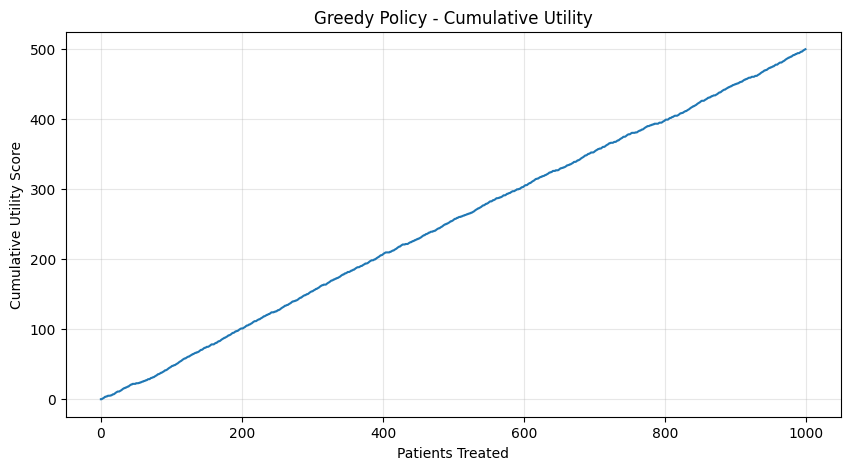

In [ ]:
# Run Greedy Policy
num_patients = 1000
env = get_clinical_trial_env()
env, rewards = run_greedy_policy(num_patients, env)
env.render()

cum_rewards = np.cumsum(rewards)
plt.figure(figsize=(10, 5))
plt.plot(cum_rewards)
plt.title('Greedy Policy - Cumulative Utility')
plt.xlabel('Patients Treated')
plt.ylabel('Cumulative Utility Score')
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** The greedy policy identifies the best medicine after the exploration phase and sticks to it. However, it risks settling on a suboptimal medicine if the exploration phase yields misleading results.

---
## Approach 2: Epsilon-Greedy Policy

The **Epsilon-Greedy Policy** improves upon the pure Greedy approach by maintaining the possibility of continuing to explore. With probability ε, it chooses a random medicine; with probability 1-ε, it exploits the best-known medicine.

- If ε = 0.1, the system explores 10% of the time and exploits 90% of the time.
- If ε = 0, purely greedy (no exploration).
- If ε = 1, purely exploratory (always random).

In [ ]:
def e_greedy_policy(i, state, num_patients, explore=10, epsilon=0.1, epsilon_count=0):
    """Epsilon-greedy policy for clinical trials."""
    bandits = len(state)
    trials = sum([len(state[b]) for b in range(bandits)])
    total_explore_trials = bandits * explore
    total_epsilon_exploration_trials = int(epsilon * (num_patients - total_explore_trials))

    # Initial exploration phase
    if trials < total_explore_trials:
        return trials % bandits, epsilon_count

    # Epsilon exploration at regular intervals
    exploration_points = np.linspace(
        total_explore_trials + 1, num_patients, total_epsilon_exploration_trials
    ).astype(int)

    if (i in exploration_points) and (epsilon_count < total_epsilon_exploration_trials):
        epsilon_count += 1
        return random.randint(0, bandits - 1), epsilon_count

    # Exploitation
    avg_rewards = [sum(state[b]) / len(state[b]) if len(state[b]) > 0 else 0
                   for b in range(bandits)]
    best_bandit = np.argmax(avg_rewards)
    return best_bandit, epsilon_count


def run_e_greedy_policy(num_patients, env, exploration=10, epsilon=0.1):
    """Run the epsilon-greedy policy for all patients."""
    state = env.reset()
    rewards = []
    epsilon_count = 0

    for i in range(num_patients):
        action, epsilon_count = e_greedy_policy(
            i, state, num_patients, exploration, epsilon, epsilon_count
        )
        state, reward, done, info = env.step(action)
        rewards.append(reward)

    env.close()
    return env, rewards

Clinical Trial Summary (Group 170, K=7)
  Medicine 0 | Trials:   23, Total Utility:    10.00, Avg Utility: 0.4348, Hidden P: 0.54
  Medicine 1 | Trials:   23, Total Utility:     8.90, Avg Utility: 0.3870, Hidden P: 0.61
  Medicine 2 | Trials:   23, Total Utility:     9.50, Avg Utility: 0.4130, Hidden P: 0.68
  Medicine 3 | Trials:  859, Total Utility:   450.90, Avg Utility: 0.5249, Hidden P: 0.75
  Medicine 4 | Trials:   20, Total Utility:     6.10, Avg Utility: 0.3050, Hidden P: 0.40
  Medicine 5 | Trials:   27, Total Utility:     9.40, Avg Utility: 0.3481, Hidden P: 0.47
  Medicine 6 | Trials:   25, Total Utility:     8.70, Avg Utility: 0.3480, Hidden P: 0.54
  Total Patients Treated: 1000
  Total Cumulative Utility: 503.50


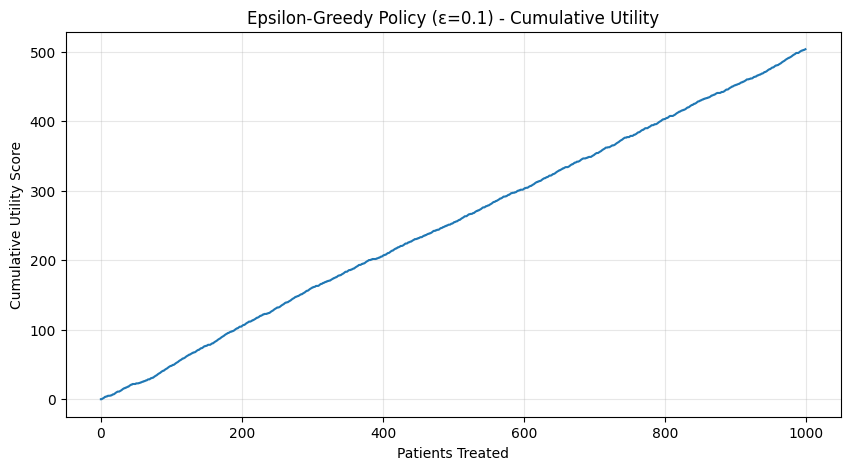

In [ ]:
# Run Epsilon-Greedy Policy
num_patients = 1000
env = get_clinical_trial_env()
env, rewards = run_e_greedy_policy(num_patients, env, exploration=10, epsilon=0.1)
env.render()

cum_rewards = np.cumsum(rewards)
plt.figure(figsize=(10, 5))
plt.plot(cum_rewards)
plt.title('Epsilon-Greedy Policy (ε=0.1) - Cumulative Utility')
plt.xlabel('Patients Treated')
plt.ylabel('Cumulative Utility Score')
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** The epsilon-greedy policy balances exploration and exploitation, continuing to sample other medicines occasionally, which helps it adapt if initial estimates were inaccurate.

---
## Approach 3: Upper Confidence Bound (UCB) Policy

The **UCB** policy uses the principle of **optimism in the face of uncertainty**. It selects the medicine with the highest upper confidence bound:

$$UCB(a) = \hat{Q}_a + \sqrt{\frac{2 \ln t}{N_a}}$$

Where:
- $\hat{Q}_a$: Estimated average utility for medicine $a$
- $t$: Total number of patients treated so far
- $N_a$: Number of times medicine $a$ has been prescribed

In [ ]:
def ucb_policy(state, t):
    """UCB policy for clinical trials."""
    bandits = len(state)
    avg_rewards = [
        sum(state[b]) / len(state[b]) if len(state[b]) > 0 else 0
        for b in range(bandits)
    ]

    confidence_bounds = [
        avg_rewards[b] + np.sqrt((2 * np.log(t + 1)) / len(state[b]))
        if len(state[b]) > 0 else float('inf')
        for b in range(bandits)
    ]
    best_bandit = np.argmax(confidence_bounds)
    return best_bandit


def run_ucb_policy(num_patients, env):
    """Run the UCB policy for all patients."""
    state = env.reset()
    rewards = []

    for t in range(num_patients):
        action = ucb_policy(state, t)
        state, reward, done, info = env.step(action)
        rewards.append(reward)

    env.close()
    return env, rewards

Clinical Trial Summary (Group 170, K=7)
  Medicine 0 | Trials:  103, Total Utility:    38.00, Avg Utility: 0.3689, Hidden P: 0.54
  Medicine 1 | Trials:   98, Total Utility:    35.40, Avg Utility: 0.3612, Hidden P: 0.61
  Medicine 2 | Trials:  207, Total Utility:    99.70, Avg Utility: 0.4816, Hidden P: 0.68
  Medicine 3 | Trials:  315, Total Utility:   167.30, Avg Utility: 0.5311, Hidden P: 0.75
  Medicine 4 | Trials:   67, Total Utility:    18.90, Avg Utility: 0.2821, Hidden P: 0.40
  Medicine 5 | Trials:   89, Total Utility:    30.80, Avg Utility: 0.3461, Hidden P: 0.47
  Medicine 6 | Trials:  121, Total Utility:    48.60, Avg Utility: 0.4017, Hidden P: 0.54
  Total Patients Treated: 1000
  Total Cumulative Utility: 438.70


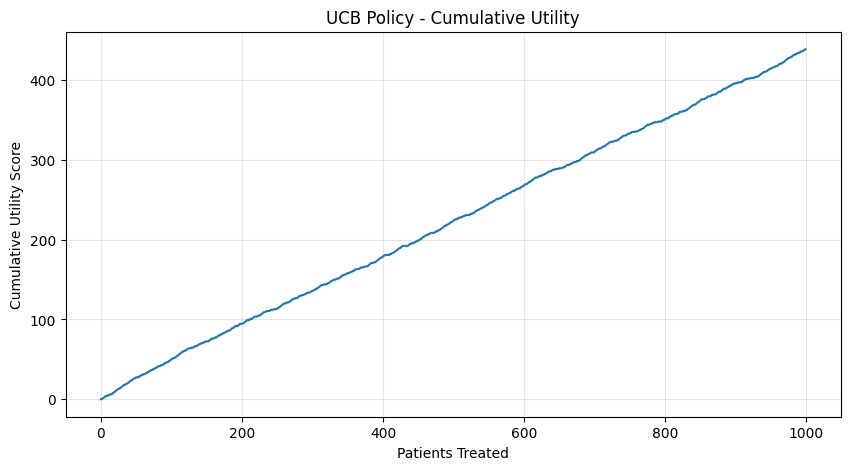

In [ ]:
# Run UCB Policy
num_patients = 1000
env = get_clinical_trial_env()
env, rewards = run_ucb_policy(num_patients, env)
env.render()

cum_rewards = np.cumsum(rewards)
plt.figure(figsize=(10, 5))
plt.plot(cum_rewards)
plt.title('UCB Policy - Cumulative Utility')
plt.xlabel('Patients Treated')
plt.ylabel('Cumulative Utility Score')
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** The UCB policy intelligently balances exploration and exploitation by favoring medicines with high average reward or high uncertainty (few trials). This often leads to faster convergence to the optimal medicine.

---
## Comparison of All Policies

We compare the cumulative utility achieved by each policy over 1000 patients.

499.00000000000006
503.5
500.8000000000001
460.3000000000003
438.70000000000005


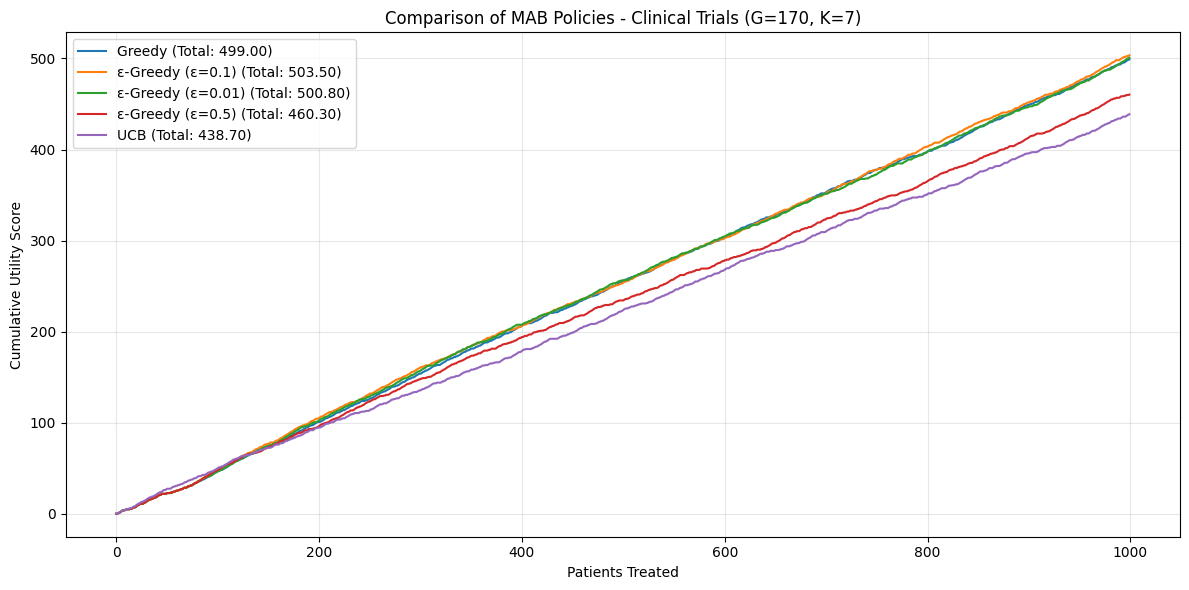


Policy                      Total Utility     Avg Utility
-------------------------------------------------------
Greedy                             499.00          0.4990
ε-Greedy (ε=0.1)                   503.50          0.5035
ε-Greedy (ε=0.01)                  500.80          0.5008
ε-Greedy (ε=0.5)                   460.30          0.4603
UCB                                438.70          0.4387


In [ ]:
# Run all policies and collect results
results = {}

# Greedy Policy
env = get_clinical_trial_env()
_, rewards_greedy = run_greedy_policy(1000, env)
results['Greedy'] = rewards_greedy

# Epsilon-Greedy Policy
env = get_clinical_trial_env()
_, rewards_egreedy = run_e_greedy_policy(1000, env, exploration=10, epsilon=0.10)
results['ε-Greedy (ε=0.1)'] = rewards_egreedy

# Epsilon-Greedy Policy
env = get_clinical_trial_env()
_, rewards_egreedy = run_e_greedy_policy(1000, env, exploration=10, epsilon=0.05)
results['ε-Greedy (ε=0.01)'] = rewards_egreedy

# Epsilon-Greedy Policy
env = get_clinical_trial_env()
_, rewards_egreedy = run_e_greedy_policy(1000, env, exploration=10, epsilon=0.5)
results['ε-Greedy (ε=0.5)'] = rewards_egreedy

# UCB Policy
env = get_clinical_trial_env()
_, rewards_ucb = run_ucb_policy(1000, env)
results['UCB'] = rewards_ucb

# Plot comparison
plt.figure(figsize=(12, 6))
for name, rewards in results.items():
    cum_rewards = np.cumsum(rewards)
    print(cum_rewards[-1])
    plt.plot(cum_rewards, label=f'{name} (Total: {cum_rewards[-1]:.2f})')

plt.title('Comparison of MAB Policies - Clinical Trials (G=170, K=7)')
plt.xlabel('Patients Treated')
plt.ylabel('Cumulative Utility Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'Policy':<25} {'Total Utility':>15} {'Avg Utility':>15}")
print(f"{'-'*55}")
for name, rewards in results.items():
    total = sum(rewards)
    avg = total / len(rewards)
    print(f"{name:<25} {total:>15.2f} {avg:>15.4f}")

---
## Exploration vs. Exploitation Summary

At first, the **agent's behavior** is aimed at **collecting data** (exploration). Then, we begin to **take actions solely based on the analysis** of the data we have collected, combining this with the **continuation of the exploration process**. After that, the **exploration process becomes minimal**, and the agent **policy acts in exploitation mode**.

### Key Insights:
- **Random Policy:** Serves as a baseline; no learning occurs.
- **Greedy Policy:** Quick to exploit after initial exploration, but may get stuck on suboptimal medicines.
- **Epsilon-Greedy:** Continues exploration throughout, providing more robust identification of the best medicine.
- **UCB:** Most principled approach; systematically balances exploration and exploitation using confidence bounds.

For clinical trials, the UCB and Epsilon-Greedy approaches are preferred as they progressively learn which medicine is most effective while minimizing the number of patients given suboptimal treatments.